# 1.Árboles de clasificación con sklearn
Algoritmo de aprendizaje supervisado para clasificación que construye un árbol de decisión dividiendo el conjunto de datos en nodos mediante reglas del tipo “si X ≤ umbral” (o por categorías). En cada partición selecciona la variable y el umbral que mejor separan las clases (p. ej., minimizando la impureza con Gini o entropía) y acaba asignando una clase final en las hojas.




## 1.1 Import
Importamos todas las librerías necesarias para este análisis: pandas, numpy, seaborn, matplotlib.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Nos importamos las funciones de árboles de scikit learn
from sklearn import tree

## 1.2 Carga el dataset de accidentes cardiacos
Para probar a hacer árboles de decisión utilizaremos un dataset sobre accidentes coronarios que he encontrado en Kaggle ([aquí](https://www.kaggle.com/andrewmvd/heart-failure-clinical-data)).


Podéis encontrar el archivo listo para importar en github: https://raw.githubusercontent.com/JimenaAreta/thevalley-MDS/refs/heads/jimena/datasets/heart_failure_clinical_records_dataset.csv .

Importa este dataset en un dataframe llamado **df**.

Descripción de columnas:
* anaemia: Decrease of red blood cells or hemoglobin (boolean)
* creatinine_phosphokinase: Level of the CPK enzyme in the blood (mcg/L)
* diabetes: If the patient has diabetes (boolean)
* ejection_fraction: Percentage of blood leaving the heart at each contraction (percentage)
* high_blood_pressure: If the patient has hypertension (boolean)
* platelets: Platelets in the blood (kiloplatelets/mL)
* serum_creatinine: Level of serum creatinine in the blood (mg/dL)
* serum_sodium: Level of serum sodium in the blood (mEq/L)
* sex: Woman or man (binary)



In [ ]:
# URL al dataset
url = " https://raw.githubusercontent.com/JimenaAreta/thevalley-MDS/refs/heads/jimena/datasets/heart_failure_clinical_records_dataset.csv"

# Importar csv
df = pd.read_csv(url)
# Visualización
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


Vamos a seleccionar las variables usadas en el ejercicio de la presentación

In [ ]:
df_resumen = df[['age', 'anaemia', 'serum_creatinine', 'DEATH_EVENT']]
df_resumen

,age,anaemia,serum_creatinine,DEATH_EVENT
0,75.0,0,1.9,1
1,55.0,0,1.1,1
2,65.0,0,1.3,1
3,50.0,1,1.9,1
4,65.0,1,2.7,1
...,...,...,...,...
294,62.0,0,1.1,0
295,55.0,0,1.2,0
296,45.0,0,0.8,0
297,45.0,0,1.4,0


In [ ]:
df_resumen.columns = ["Edad", "Anemia", "Serum", "Fallece"]
df_resumen

,Edad,Anemia,Serum,Fallece
0,75.0,0,1.9,1
1,55.0,0,1.1,1
2,65.0,0,1.3,1
3,50.0,1,1.9,1
4,65.0,1,2.7,1
...,...,...,...,...
294,62.0,0,1.1,0
295,55.0,0,1.2,0
296,45.0,0,0.8,0
297,45.0,0,1.4,0


# 2.Inicializamos el árbol
Definiendo las características que tendrá.

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier

In [ ]:
# Inicializamos un árbol. Por ahora está vacío.
# Solo definimos cómo queremos que sea en cuanto a su estructura y condiciones de entrenamiento
arbol = tree.DecisionTreeClassifier(max_depth=3) #con el max depth le estoy diciendo que como maximo quiero que tenga una profundidad de 3, por ejemplo
#sino por codigo sería hasta mucho mas
arbol

DecisionTreeClassifier(max_depth=3)

# 3.Entrenamos el modelo
Una vez inicializado y definido el árbol, el método .[fit()](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier.fit) realiza el proceso de particionado recursivo que hemos hecho nosotros antes a mano.

In [ ]:
df_resumen[["Edad", "Serum", "Anemia"]].shape

(299, 3)

In [ ]:
df_resumen[["Fallece"]].shape

(299, 1)

In [ ]:
# Entrenamos el árbol inicializado a partir de los datos que le pasemos con .fit()
arbol.fit(
    X=df_resumen[["Edad", "Serum", "Anemia"]],  # vars descriptivas
    y=df_resumen[["Fallece"]],                  # var objetivo
)
arbol

DecisionTreeClassifier(max_depth=3)

# 4. Visualizamos el modelo
Una vez entrenado el modelo, podemos visualizarlo.

In [ ]:
# Con el método export_text en un print()
esquema_print = tree.export_text(arbol, feature_names=["Edad", "Serum", "Anemia"])
print(esquema_print)

|--- Serum <= 1.81
|   |--- Edad <= 79.50
|   |   |--- Serum <= 0.95
|   |   |   |--- class: 0
|   |   |--- Serum >  0.95
|   |   |   |--- class: 0
|   |--- Edad >  79.50
|   |   |--- Serum <= 0.95
|   |   |   |--- class: 0
|   |   |--- Serum >  0.95
|   |   |   |--- class: 1
|--- Serum >  1.81
|   |--- Serum <= 2.05
|   |   |--- class: 1
|   |--- Serum >  2.05
|   |   |--- Serum <= 6.45
|   |   |   |--- class: 1
|   |   |--- Serum >  6.45
|   |   |   |--- class: 1



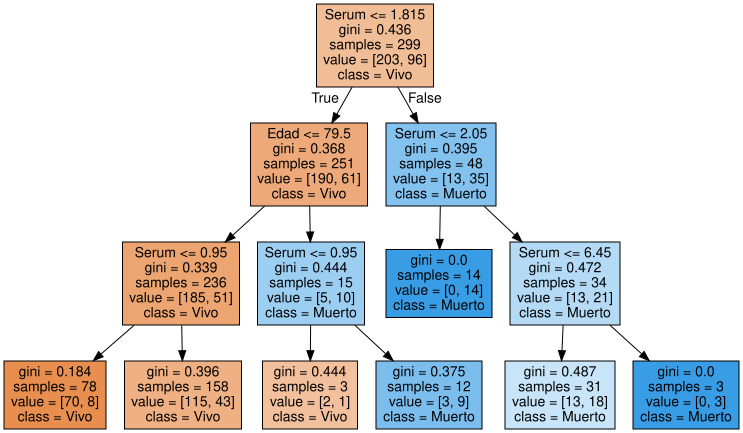

In [ ]:
# Con la librería graphviz
import graphviz

# Export_graphviz
dot_data = tree.export_graphviz(
    arbol, out_file=None, feature_names=["Edad", "Serum", "Anemia"], class_names=["Vivo", "Muerto"], filled=True #class_names sirve para decirle 0 es vivo, 1 es muerto, y filled true nos da colores
)
graph = graphviz.Source(dot_data)
graph

## EJERCICIO

  Mostrar el valor de la clase en el arbol mostrado con graphviz

Nota:
buscar solución en: https://scikit-learn.org/stable/modules/generated/sklearn.tree.export_graphviz.html

# 5.Realizamos una predicción
Una vez el modelo está entrenado (definido) podemos pasarle datos para obtener las prediciones correspondientes de la variable objetivo.

Para esto utilizamos el método .[predict()](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier.predict).

In [ ]:
# Predicción
prediccion = arbol.predict(df_resumen[["Edad", "Serum", "Anemia"]])
prediccion

array([1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
# También podemos sacar las probabilidades
arbol.predict_proba(df_resumen[["Edad", "Serum", "Anemia"]])[:,1][0:20]

array([1.        , 0.2721519 , 0.2721519 , 1.        , 0.58064516,
       0.58064516, 0.2721519 , 0.2721519 , 0.2721519 , 1.        ,
       0.58064516, 0.1025641 , 0.2721519 , 0.2721519 , 0.2721519 ,
       0.75      , 0.33333333, 0.1025641 , 0.2721519 , 1.        ])

In [ ]:
# Comparo el resultado de la prediccion con df_resumen
df_resumen[["Edad", "Serum", "Anemia", "Fallece"]]

,Edad,Serum,Anemia,Fallece
0,75.0,1.9,0,1
1,55.0,1.1,0,1
2,65.0,1.3,0,1
3,50.0,1.9,1,1
4,65.0,2.7,1,1
...,...,...,...,...
294,62.0,1.1,0,0
295,55.0,1.2,0,0
296,45.0,0.8,0,0
297,45.0,1.4,0,0


In [ ]:
# Cómo de buena es la predicción?
from sklearn.metrics import accuracy_score

accuracy_score(df_resumen["Fallece"], prediccion)

# ¿Que significa este resultado?
#en un 77% de los valores acierta

0.7725752508361204

## EJERCICIO con todas las características
Entrenamos de nuevo el árbol de decisión:
* con todas las variables del set de datos de accidente cardiaco,
* quitamos si alguna vemos que no aplica
* Utilizamos un max_depth=6
* y evaluamos si la predicción es mejor o peor que utilizando tres variables.

**¿Deberíamos evaluar de esta forma los modelos?**

# EJERCICIO Partiendo training y test data

Repetir la predicción pero partiendo el dataset en training y test data.

```
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
```

# EJERCICIO TITANIC
Vamos a hacer un árbol de decisión que prediga si alguien fallece o no (survived)

Para ello utilizaremos un dataset previamente transformado, ya listo para entrenar un árbol. Puedes encontrarlo en github. Este es el link al archivo raw: [https://raw.githubusercontent.com/JimenaAreta/thevalley-MDS/refs/heads/jimena/datasets/titanic_limpio.csv](https://raw.githubusercontent.com/JimenaAreta/thevalley-MDS/refs/heads/jimena/datasets/titanic_limpio.csv)

* Importa los datos en un dataframe llamado **dataframe df_titanic**.
* Crea el árbol de clasificación
* Entrénalo.
* Realiza una predicción.
* Evalua la calidad del entrenamiento.

Campos:
* Survived: Variable factor, 1 (el pasajero sobrevivió) 0 (el pasajero no sobrevivió).
* Pclass: En que clase viajaba el pasajero (1 = primera, 2 = segunda, 3 = * tercera).
* Sex: Sexo del pasajero.
* Age: Edad del pasajero.
* SibSp: Cantidad de hermanos o cónyuges a bordo del Titanic.
* Parch: Cantidad de padres o hijos a bordo del Titanic.
* Fare: Tarifa del pasajero.
* Embarked: Puerto donde embarco el pasajero (C = Cherbourg, Q = Queenstown, S = Southampton


In [ ]:
# URL al dataset
url = " https://raw.githubusercontent.com/JimenaAreta/thevalley-MDS/refs/heads/jimena/datasets/heart_failure_clinical_records_dataset.csv"

# Importar csv
df = pd.read_csv(url)
# Visualización
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [ ]:
df_resumen_2 = df[['age', 'anaemia', 'serum_creatinine', 'DEATH_EVENT']]
df_resumen_2

,age,anaemia,serum_creatinine,DEATH_EVENT
0,75.0,0,1.9,1
1,55.0,0,1.1,1
2,65.0,0,1.3,1
3,50.0,1,1.9,1
4,65.0,1,2.7,1
...,...,...,...,...
294,62.0,0,1.1,0
295,55.0,0,1.2,0
296,45.0,0,0.8,0
297,45.0,0,1.4,0


In [ ]:
df_resumen_2.columns = ["Edad", "Anemia", "Serum", "Fallece"]
df_resumen_2

,Edad,Anemia,Serum,Fallece
0,75.0,0,1.9,1
1,55.0,0,1.1,1
2,65.0,0,1.3,1
3,50.0,1,1.9,1
4,65.0,1,2.7,1
...,...,...,...,...
294,62.0,0,1.1,0
295,55.0,0,1.2,0
296,45.0,0,0.8,0
297,45.0,0,1.4,0


In [ ]:
arbol_2 = tree.DecisionTreeClassifier(max_depth=6)
arbol_2

DecisionTreeClassifier(max_depth=6)

In [ ]:
X=df_resumen_2[["Edad", "Serum", "Anemia"]]  # vars descriptivas
y=df_resumen_2[["Fallece"]]                # var objetivo

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
arbol_2.fit(
    X_train,  # vars descriptivas
    y_train,                  # var objetivo
)
arbol_2

DecisionTreeClassifier(max_depth=6)

In [ ]:
# Con el método export_text en un print()
esquema_print = tree.export_text(arbol_2, feature_names=["Edad", "Serum", "Anemia"])
print(esquema_print)

|--- Serum <= 1.81
|   |--- Edad <= 81.50
|   |   |--- Serum <= 0.95
|   |   |   |--- Serum <= 0.65
|   |   |   |   |--- Serum <= 0.55
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Serum >  0.55
|   |   |   |   |   |--- class: 1
|   |   |   |--- Serum >  0.65
|   |   |   |   |--- Serum <= 0.85
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Serum >  0.85
|   |   |   |   |   |--- Edad <= 62.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- Edad >  62.50
|   |   |   |   |   |   |--- class: 0
|   |   |--- Serum >  0.95
|   |   |   |--- Edad <= 64.50
|   |   |   |   |--- Edad <= 57.50
|   |   |   |   |   |--- Edad <= 44.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- Edad >  44.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- Edad >  57.50
|   |   |   |   |   |--- Serum <= 1.60
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- Serum >  1.60
|   |   |   |   |   |   |--- class: 0
|   |   |   |--- Edad >  64.50
|   | 

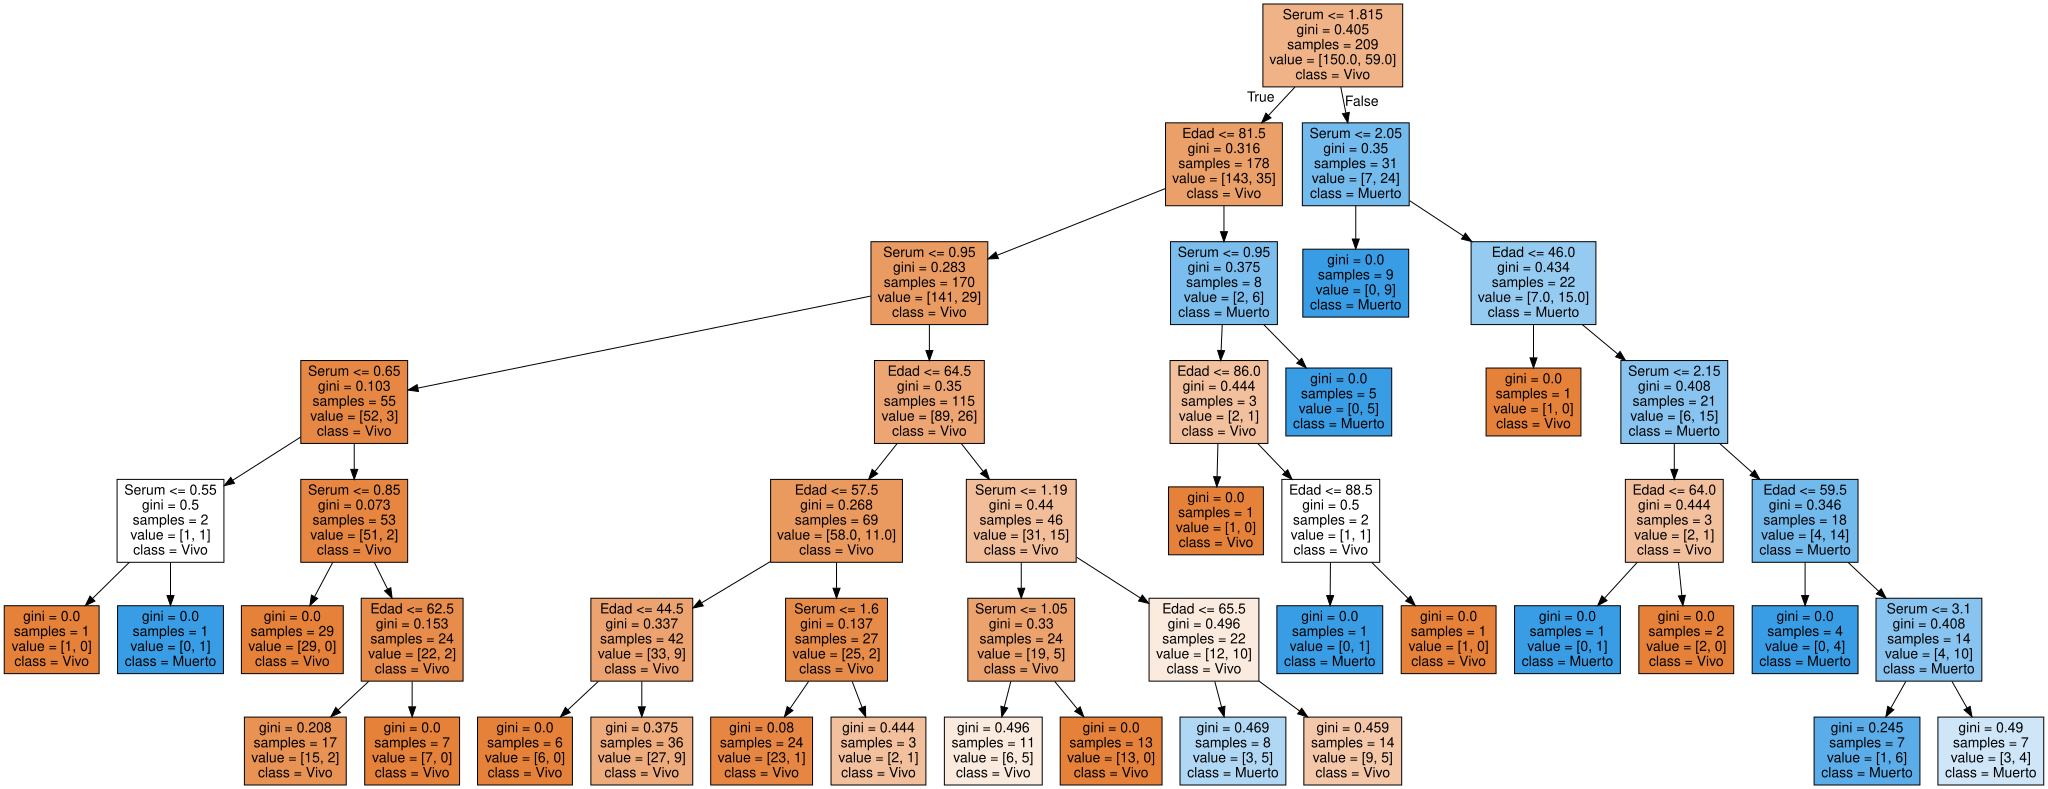

In [ ]:
# Con la librería graphviz
import graphviz

# Export_graphviz
dot_data = tree.export_graphviz(
    arbol_2, out_file=None, feature_names=["Edad", "Serum", "Anemia"], class_names=["Vivo", "Muerto"], filled=True #class_names sirve para decirle 0 es vivo, 1 es muerto, y filled true nos da colores
)
graph = graphviz.Source(dot_data)
graph

In [ ]:
# Predicción
prediccion_2 = arbol_2.predict(df_resumen[["Edad", "Serum", "Anemia"]])
prediccion_2

array([1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
# También podemos sacar las probabilidades
arbol_2.predict_proba(df_resumen[["Edad", "Serum", "Anemia"]])[:,1][0:20]

array([1.        , 0.25      , 0.625     , 1.        , 0.85714286,
       0.        , 0.35714286, 0.04166667, 0.625     , 0.57142857,
       0.57142857, 0.11764706, 0.25      , 0.25      , 0.25      ,
       1.        , 1.        , 0.        , 0.45454545, 1.        ])

In [ ]:
# Comparo el resultado de la prediccion con df_resumen
df_resumen_2[["Edad", "Serum", "Anemia", "Fallece"]]

,Edad,Serum,Anemia,Fallece
0,75.0,1.9,0,1
1,55.0,1.1,0,1
2,65.0,1.3,0,1
3,50.0,1.9,1,1
4,65.0,2.7,1,1
...,...,...,...,...
294,62.0,1.1,0,0
295,55.0,1.2,0,0
296,45.0,0.8,0,0
297,45.0,1.4,0,0


In [ ]:
# Cómo de buena es la predicción?
from sklearn.metrics import accuracy_score

accuracy_score(df_resumen_2["Fallece"], prediccion_2)

# ¿Que significa este resultado?
#en un 77% de los valores acierta

0.782608695652174

**TITANIC**

In [ ]:
# URL al dataset
url = "https://raw.githubusercontent.com/JimenaAreta/thevalley-MDS/refs/heads/jimena/datasets/titanic_limpio.csv"

# Importar csv
df = pd.read_csv(url)
# Visualización
df.head()

,Survived,Pclass,Sex,SibSp,Parch,Fare,Age,Embarked_C,Embarked_Q,Embarked_S
0,0,3,1,1,0,7.2500,22.0,0,0,1
1,1,1,0,1,0,71.2833,38.0,1,0,0
2,1,3,0,0,0,7.9250,26.0,0,0,1
3,1,1,0,1,0,53.1000,35.0,0,0,1
4,0,3,1,0,0,8.0500,35.0,0,0,1
